In [1]:
CONFIG = {
    "dataset": 'NFCorpus',
    "dataset_url": "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/nfcorpus.zip",
    "results_dir": "results",
    "dense_model": "sentence-transformers/all-MiniLM-L6-v2",
    "dense_batch_size": 64,
    "top_k": 10,
    "top_k_eval": [1, 3, 5, 10],
    "delta": 0.05,
    "n_bootstrap": 10000
}


COLORS = {
    "BM25": "#e74c3c",
    "Dense": "#3498db",
    "Hybrid": "#2ecc71",
}

In [2]:
from beir import util
from beir.datasets.data_loader import GenericDataLoader
import os


data_path = os.path.join("datasets", CONFIG["dataset"])
if not os.path.exists(data_path):
    print("Downloading NFCorpus...")
    data_path = util.download_and_unzip(CONFIG["dataset_url"], "datasets")
    print(f"Downloaded to: {data_path}")
else:
    print(f"Dataset already exists at: {data_path}")


corpus, test_queries, test_qrels = GenericDataLoader(data_path).load(split="test")
_, train_queries, train_qrels = GenericDataLoader(data_path).load(split="train")
_, dev_queries, dev_qrels = GenericDataLoader(data_path).load(split="dev")

print(f"\n{'='*50}")
print(f"  NFCorpus Dataset Summary")
print(f"{'='*50}")

print(f"  Corpus:        {len(corpus):,} documents")
print(f"  Train queries: {len(train_queries):,}  |  Train qrels: {sum(len(v) for v in train_qrels.values()):,}")
print(f"  Dev queries:   {len(dev_queries):,}  |  Dev qrels:   {sum(len(v) for v in dev_qrels.values()):,}")
print(f"  Test queries:  {len(test_queries):,}  |  Test qrels:  {sum(len(v) for v in test_qrels.values()):,}")
print(f"{'='*50}")

Dataset already exists at: datasets/NFCorpus


/Users/dmitrijnaumov/Code/Inno/AdvancedML/RAGEval/.venv/lib/python3.12/site-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/3633 [00:00<?, ?it/s]

  0%|          | 0/3633 [00:00<?, ?it/s]

  0%|          | 0/3633 [00:00<?, ?it/s]


  NFCorpus Dataset Summary
  Corpus:        3,633 documents
  Train queries: 2,590  |  Train qrels: 110,575
  Dev queries:   324  |  Dev qrels:   11,385
  Test queries:  323  |  Test qrels:  12,334


In [3]:
doc_ids = list(corpus.keys())
doc_texts = [
    (corpus[did].get("title", "") + " " + corpus[did].get("text", "")).strip()
    for did in doc_ids
]

print(f"Prepared {len(doc_ids):,} documents for indexing.")
print(f"\nExample document (first 300 chars):")
print(f"  ID:   {doc_ids[0]}")
print(f"  Text: {doc_texts[0][:300]}...")

Prepared 3,633 documents for indexing.

Example document (first 300 chars):
  ID:   MED-10
  Text: Statin Use and Breast Cancer Survival: A Nationwide Cohort Study from Finland Recent studies have suggested that statins, an established drug group in the prevention of cardiovascular mortality, could delay or prevent breast cancer recurrence but the effect on disease-specific mortality remains uncl...


In [4]:
from collections import Counter
import numpy as np


doc_lengths = [len(text.split()) for text in doc_texts]

query_lengths = [len(q.split()) for q in test_queries.values()]

all_relevances = []
for qid in test_qrels:
    for did, rel in test_qrels[qid].items():
        all_relevances.append(rel)
rel_counts = Counter(all_relevances)

rels_per_query = [len(test_qrels[qid]) for qid in test_qrels]

print(f"Document Length Statistics:")
print(f"  Mean:   {np.mean(doc_lengths):.1f} words")
print(f"  Median: {np.median(doc_lengths):.1f} words")
print(f"  Min:    {np.min(doc_lengths)} words")
print(f"  Max:    {np.max(doc_lengths)} words")

print(f"\nQuery Length Statistics:")
print(f"  Mean:   {np.mean(query_lengths):.1f} words")
print(f"  Median: {np.median(query_lengths):.1f} words")

print(f"\nRelevance Distribution (test split):")
for rel_level in sorted(rel_counts.keys()):
    count = rel_counts[rel_level]
    print(f"  Level {rel_level}: {count:,} ({count/len(all_relevances)*100:.1f}%)")

print(f"\nRelevant Docs per Query:")
print(f"  Mean:   {np.mean(rels_per_query):.1f}")
print(f"  Median: {np.median(rels_per_query):.1f}")
print(f"  Max:    {np.max(rels_per_query)}")

Document Length Statistics:
  Mean:   233.8 words
  Median: 237.0 words
  Min:    17 words
  Max:    1481 words

Query Length Statistics:
  Mean:   3.3 words
  Median: 2.0 words

Relevance Distribution (test split):
  Level 1: 11,758 (95.3%)
  Level 2: 576 (4.7%)

Relevant Docs per Query:
  Mean:   38.2
  Median: 16.0
  Max:    475


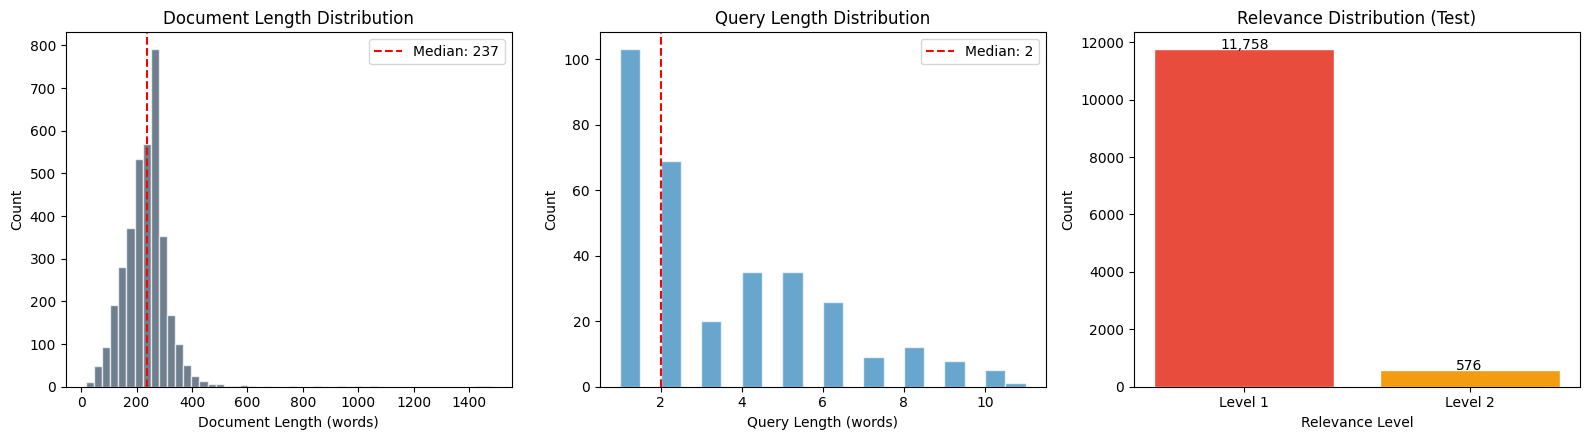

Figure saved.


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Plot 1: Document length distribution
axes[0].hist(doc_lengths, bins=50, color="#34495e", alpha=0.7, edgecolor="white")
axes[0].axvline(np.median(doc_lengths), color="red", linestyle="--",
                label=f"Median: {np.median(doc_lengths):.0f}")
axes[0].set_xlabel("Document Length (words)")
axes[0].set_ylabel("Count")
axes[0].set_title("Document Length Distribution")
axes[0].legend()

# Plot 2: Query length distribution
axes[1].hist(query_lengths, bins=20, color="#2980b9", alpha=0.7, edgecolor="white")
axes[1].axvline(np.median(query_lengths), color="red", linestyle="--",
                label=f"Median: {np.median(query_lengths):.0f}")
axes[1].set_xlabel("Query Length (words)")
axes[1].set_ylabel("Count")
axes[1].set_title("Query Length Distribution")
axes[1].legend()

# Plot 3: Relevance distribution
rel_labels = [f"Level {k}" for k in sorted(rel_counts.keys())]
rel_values = [rel_counts[k] for k in sorted(rel_counts.keys())]
bars = axes[2].bar(rel_labels, rel_values, color=["#e74c3c", "#f39c12", "#27ae60"],
                   edgecolor="white")
for bar, val in zip(bars, rel_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"{val:,}", ha="center", fontsize=10)
axes[2].set_xlabel("Relevance Level")
axes[2].set_ylabel("Count")
axes[2].set_title("Relevance Distribution (Test)")

plt.tight_layout()
os.makedirs(CONFIG["results_dir"], exist_ok=True)
plt.savefig(os.path.join(CONFIG["results_dir"], "dataset_exploration.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

In [6]:
print("=" * 70)
print("  Example Queries with Relevant Documents")
print("=" * 70)

example_count = 0
for qid, query_text in test_queries.items():
    if qid not in test_qrels or example_count >= 3:
        break

    print(f"\n  Query [{qid}]: \"{query_text}\"")
    print(f"  Number of relevant documents: {len(test_qrels[qid])}")

    # Show top 2 relevant docs sorted by relevance
    sorted_rels = sorted(test_qrels[qid].items(), key=lambda x: -x[1])
    for did, rel in sorted_rels[:2]:
        title = corpus[did].get("title", "No title")
        text_preview = corpus[did].get("text", "")[:120]
        print(f"    → [{did}] relevance={rel}")
        print(f"      Title: {title}")
        print(f"      Text:  {text_preview}...")

    example_count += 1

print("\n" + "=" * 70)

  Example Queries with Relevant Documents

  Query [PLAIN-2]: "Do Cholesterol Statin Drugs Cause Breast Cancer?"
  Number of relevant documents: 24
    → [MED-2427] relevance=2
      Title: Elevated Levels of Cholesterol-Rich Lipid Rafts in Cancer Cells Are Correlated with Apoptosis Sensitivity Induced by Cholesterol-Depleting Agents
      Text:  Lipid rafts/caveolae are membrane platforms for signaling molecules that regulate various cellular functions, including ...
    → [MED-10] relevance=2
      Title: Statin Use and Breast Cancer Survival: A Nationwide Cohort Study from Finland
      Text:  Recent studies have suggested that statins, an established drug group in the prevention of cardiovascular mortality, cou...

  Query [PLAIN-12]: "Exploiting Autophagy to Live Longer"
  Number of relevant documents: 30
    → [MED-2513] relevance=2
      Title: Insights into the beneficial effect of caloric/ dietary restriction for a healthy and prolonged life
      Text:  Over the last several 